# 🏁 Race Analysis

Now that the race has been revealed, it's time to delve deeper into why did McLaren end up with second and fourth positions instead of first and second.

## ⚙️ Environment setup

In [1]:
import fastf1 as ff1
from fastf1 import plotting
from fastf1.logger import set_log_level
from matplotlib import pyplot as plt

from plots.laps import plot_driver_lap_time_distributions, plot_lap_time_box_plots
from plots.positions import plot_position_changes, plot_starting_grid
from plots.tyres import plot_tyre_strategy

set_log_level("ERROR")
plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")

%matplotlib widget

## 📚 Aggregating and cleaning data

In [2]:
race = ff1.get_session(2025, "Qatar", "R")
race.load(telemetry=False)

In [3]:
results = race.results

In [4]:
grid = results[results["GridPosition"] > 0].sort_values(by="GridPosition")
pit_lane_starters = results[results["GridPosition"] == 0]

In [5]:
race_laps = race.laps.copy()
race_laps.loc[:, "LapTime_s"] = race_laps.LapTime.dt.total_seconds()

In [6]:
race_push_laps = race_laps.pick_quicklaps().copy()

In [7]:
stints = race_laps[["Driver", "Stint", "Compound", "LapNumber"]]
stints = stints.groupby(["Driver", "Stint", "Compound"])
stints = stints.count().reset_index()
stints = stints.rename(columns={"LapNumber": "StintLength"})

In [8]:
drivers = [race.get_driver(driver)["Abbreviation"] for driver in race.drivers]

In [9]:
point_finishers = race.drivers[:10]

In [10]:
driver_laps = race_push_laps.pick_drivers(point_finishers)
driver_laps = driver_laps.reset_index()

In [11]:
finishing_order = [race.get_driver(i)["Abbreviation"] for i in point_finishers]

## 🔬 Analysis

Let's take a look at the starting grid!

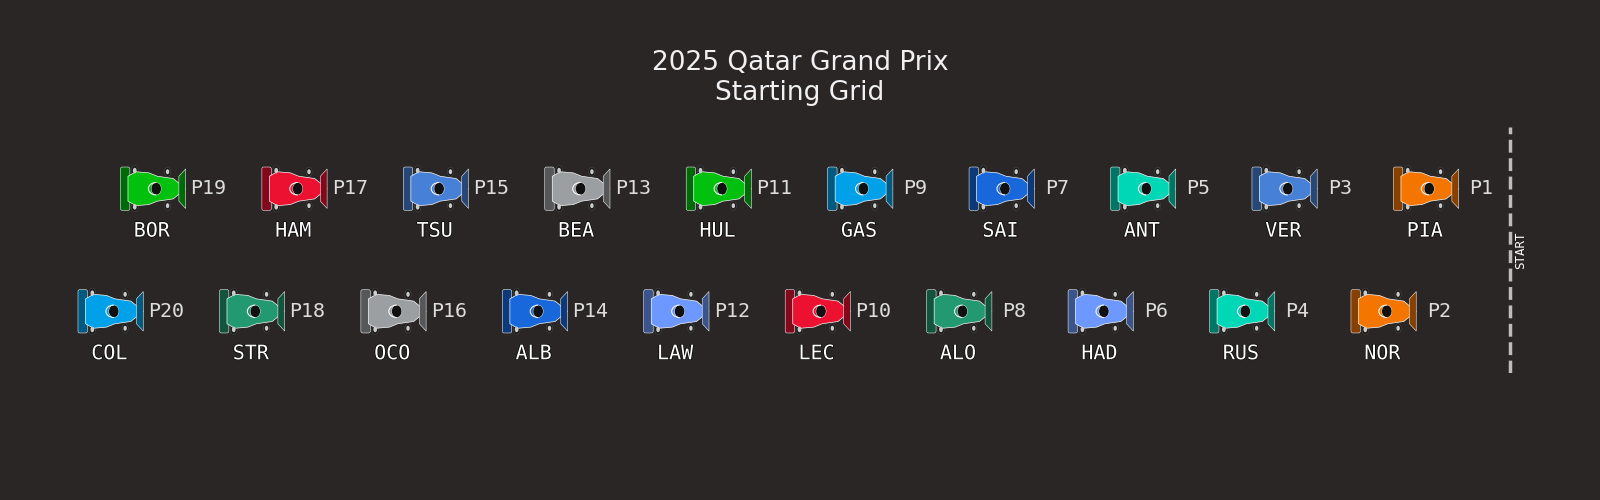

In [12]:
plot_starting_grid(race)

Notice that overtakes on the start of the race are not registered in the following plot. Here, it is possible to notice that Verstappen loses his position to Norris due to the pit at 7th lap, and as the McLarens pit, he climbs up to P1, gets once again overtaken as he pits, just to go back to P1 after McLarens have to pit yet again.

In [13]:
race.event.EventName

'Qatar Grand Prix'

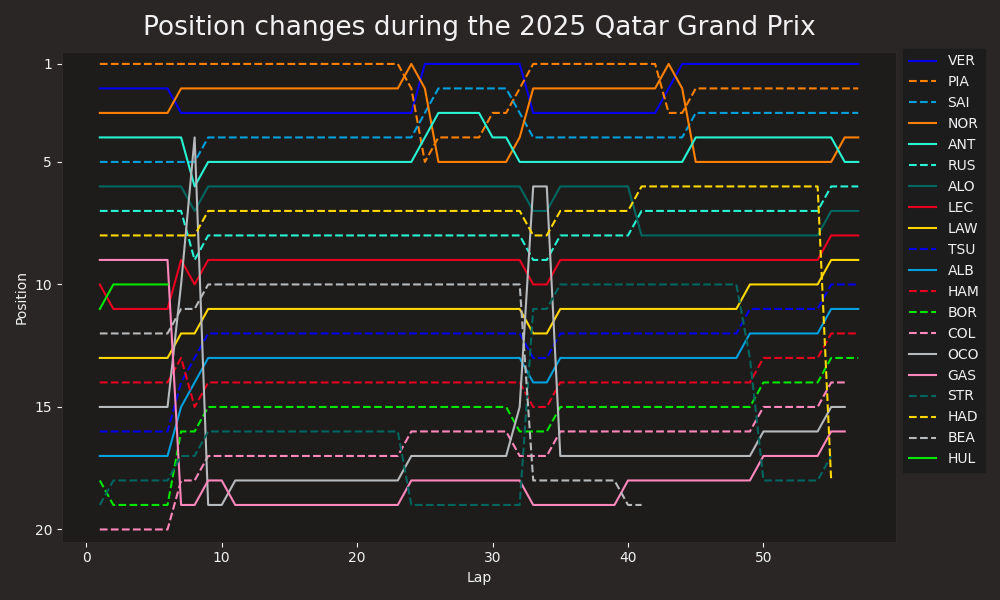

In [14]:
plot_position_changes(race)

There is, however, in this race, an underdog story! Sainz capitalized on Williams' great pace this weekend. Starting from P7, he overtook both Racing Bulls' Hadjar and Mercedes' Russell for P5 in the first lap. He also had a great pit stop, enabling him to cut a lot of time and overtake Antonelli. As the McLarens pitted, he climbed up to P2! He was not able, he was then overtook by both McLarens, going back to P4, but as the McLarens pitted once again, he was able to hold onto P3.

This was a big highlight, as before Sainz's run in Williams in 2025, the last time the team achieved a podium finish in a full race was back in 2017, and secured a P5 for Williams Racing's constructor championship.

https://www.formula1.com/en/video/2025-qatar-grand-prix-sainz-crosses-the-line-to-take-an-unbelievable-podium-finish.1850249091945216620 

This is a great example of how aligning good pace with good race strategy and opportunism can be decisive in F1.

As the push laps are analyzed, it is possible to notice that during the race, Williams Racing had the third best lap time median, very close to Ferrari, but more variable. As for McLaren, it had the best lap times of all the teams by a significant margin in F1's reality.

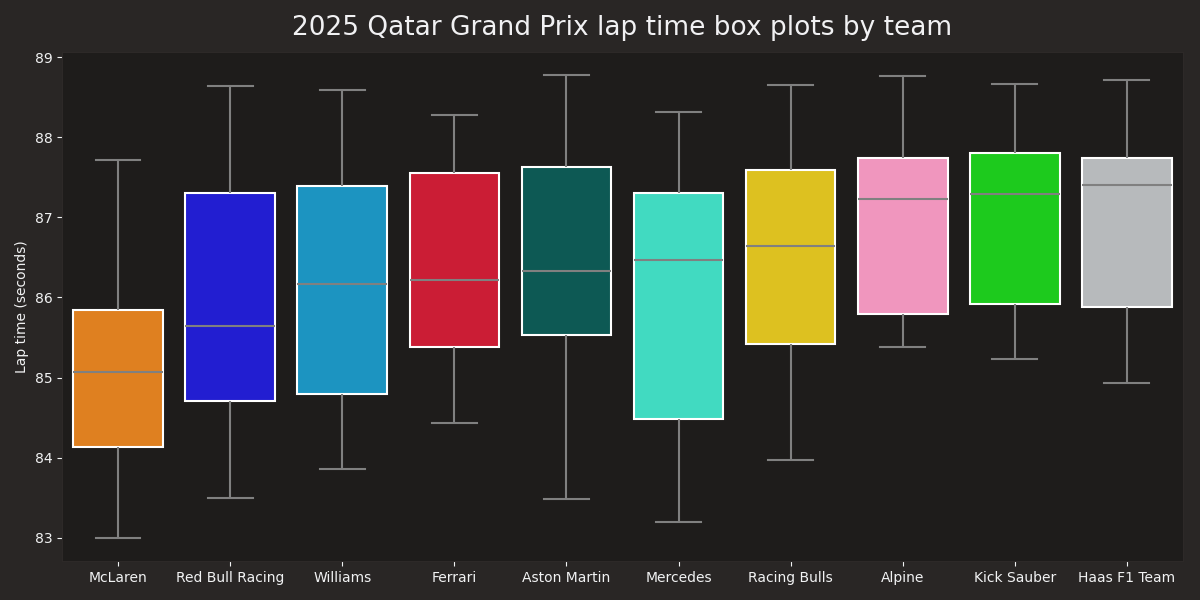

In [15]:
plot_lap_time_box_plots(race_push_laps, race, mode="Team")

Both McLaren drivers were able to outpace Max in push laps. And even though his position was P3, Sainz actually had the 5th best pace.

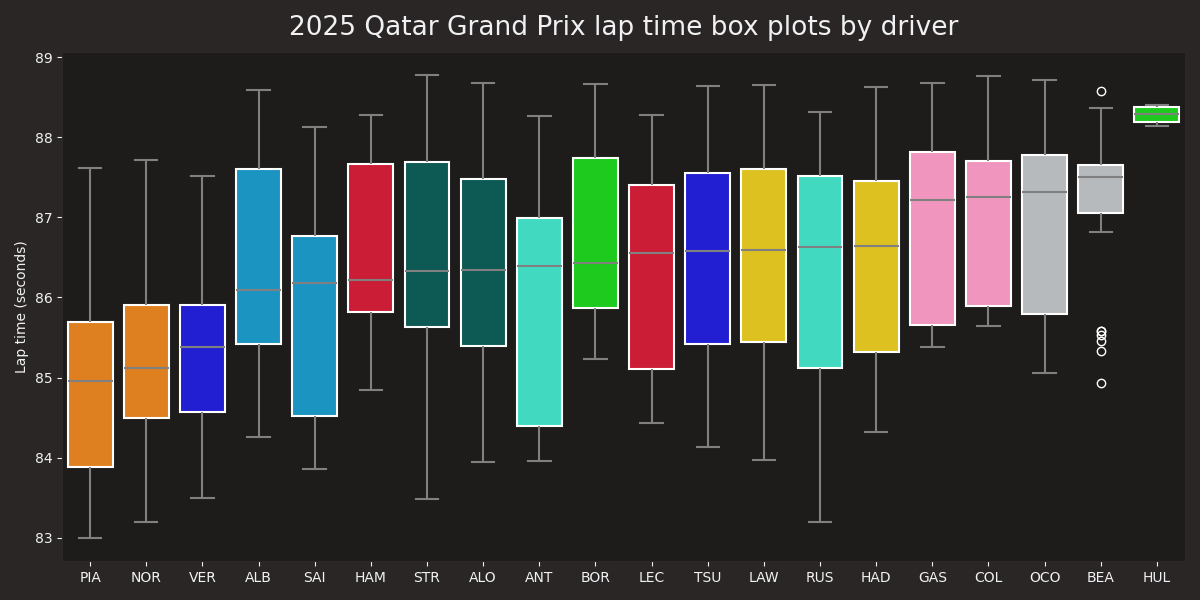

In [16]:
plot_lap_time_box_plots(race_push_laps, race, mode="Driver")

These are the push laps for points finishers, ordered by the finishing order, with the added complexity of tyre compounds being used. Here, it is possible to notice a higher variance in medium tyres lap times for McLaren drivers when compared to both Sainz and Verstappen.

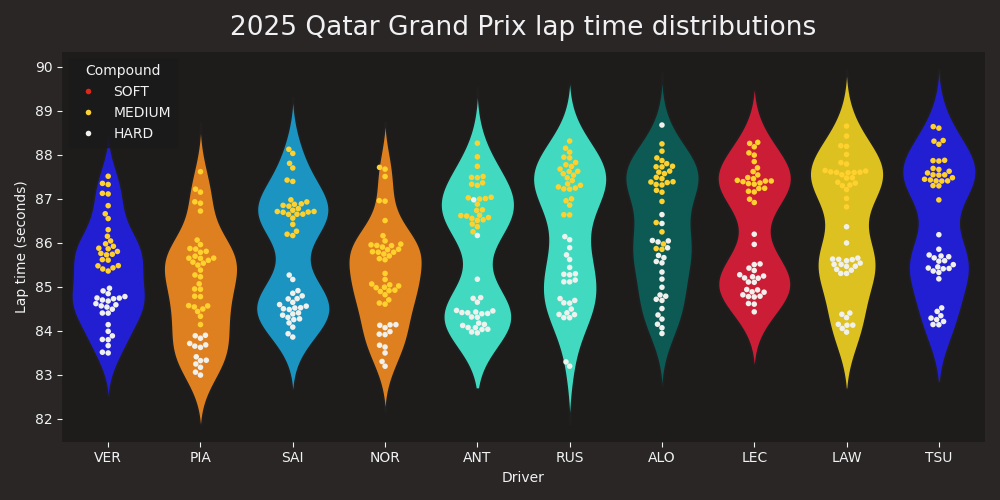

In [17]:
plot_driver_lap_time_distributions(
    driver_laps,
    finishing_order,
    race,
)

When it comes to push laps, it is actually possible to see that Sainz was slower in many laps before actually approaching a performance very similar to the other drivers.

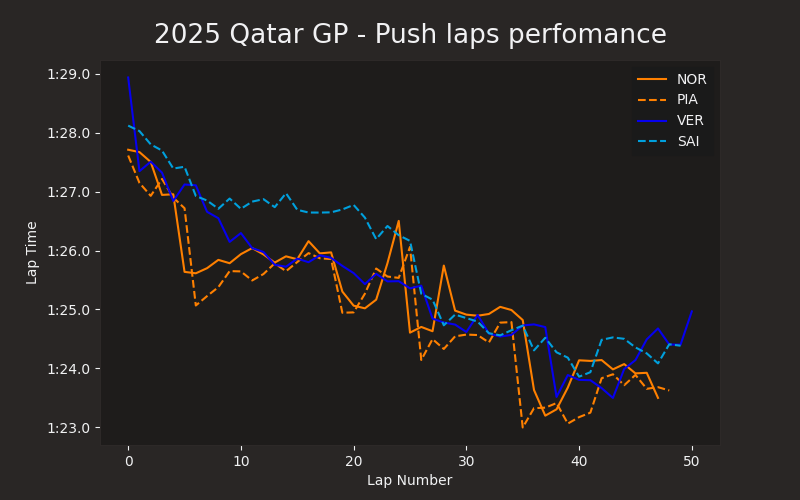

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

for driver in ("NOR", "PIA", "VER", "SAI"):
    laps = race.laps.pick_drivers(driver).pick_quicklaps().reset_index()
    style = plotting.get_driver_style(
        identifier=driver,
        style=["color", "linestyle"],
        session=race,
    )
    ax.plot(laps["LapTime"], **style, label=driver)

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")
ax.legend()
ax.set_title("2025 Qatar GP - Push laps perfomance")
plotting.add_sorted_driver_legend(ax, race)
plt.show()

But finally, when we remove the normalization of push laps, we can truly see the spike in lap times that almost cost McLaren's driver championship in 2025 for Lando Norris.

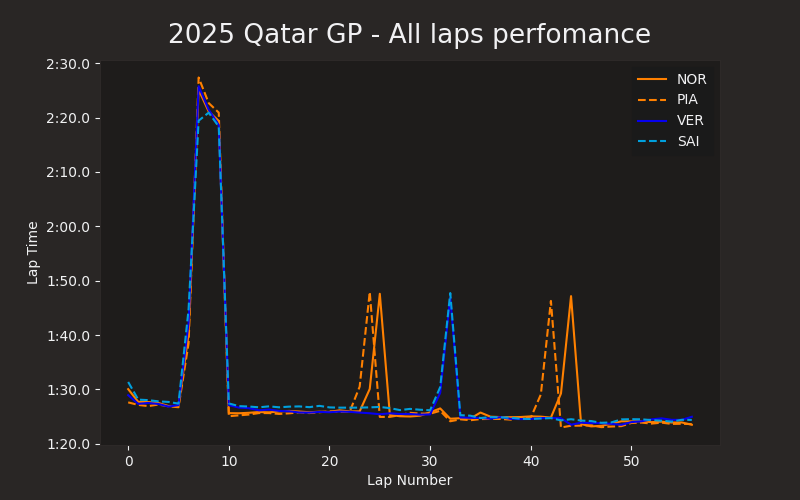

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

for driver in ("NOR", "PIA", "VER", "SAI"):
    laps = race.laps.pick_drivers(driver).reset_index()
    style = plotting.get_driver_style(
        identifier=driver,
        style=["color", "linestyle"],
        session=race,
    )
    ax.plot(laps["LapTime"], **style, label=driver)

ax.set_xlabel("Lap Number")
ax.set_ylabel("Lap Time")
ax.set_title("2025 Qatar GP - All laps perfomance")
ax.legend()
plotting.add_sorted_driver_legend(ax, race)
plt.show()

Due to the late pits, McLaren actually had three big spikes in lap time, instead of 3. Also, the drivers, under safety car, were not able to capitalize by staying out. They had very similar (or worse) lap times than Verstappen, who pitted. Sainz actually was faster than all 3 during this pit.

And since no other safety car was deployed, McLaren had lost the only opportunity that they had for a free pit stop. Unlike previous years, who at least had 3 safety cars deployed, this one had just this one.

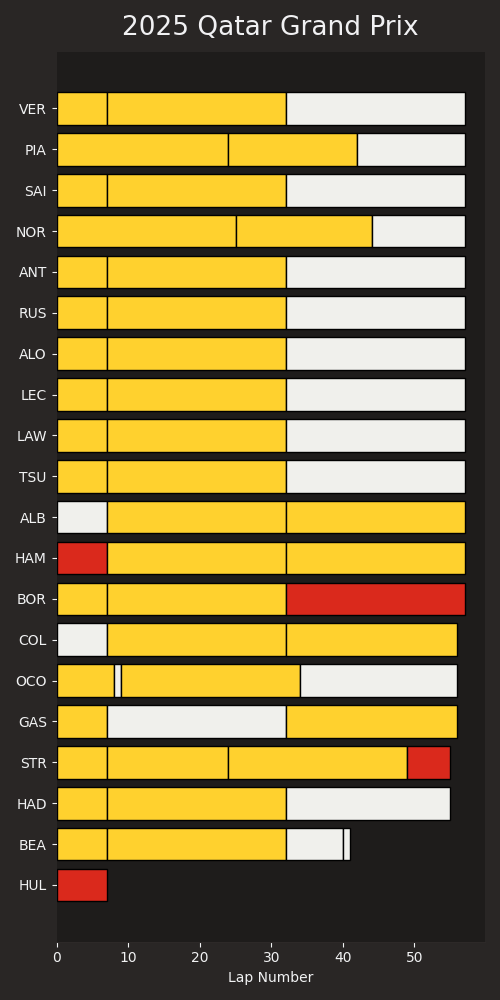

In [20]:
plot_tyre_strategy(drivers, stints, race)

This made Verstappen chirp away 13 points from Norris. He needed a 12 point advantage in the last race of the season to be able to cause a draw.

And by just two points, he almost did it. He was once on a 104 deficit to the leader in the WDC this season.

https://www.formula1.com/en/results/2025/drivers

> This race almost cost Lando Norris' world driver championship.

As for Piastri, this result made his chances to win the WDC in the last race very, very narrow. He ended up finishing P3 by a 11 point difference to Verstappen, 7 of those coming from this single race.

## 🌱 Future works and improvements